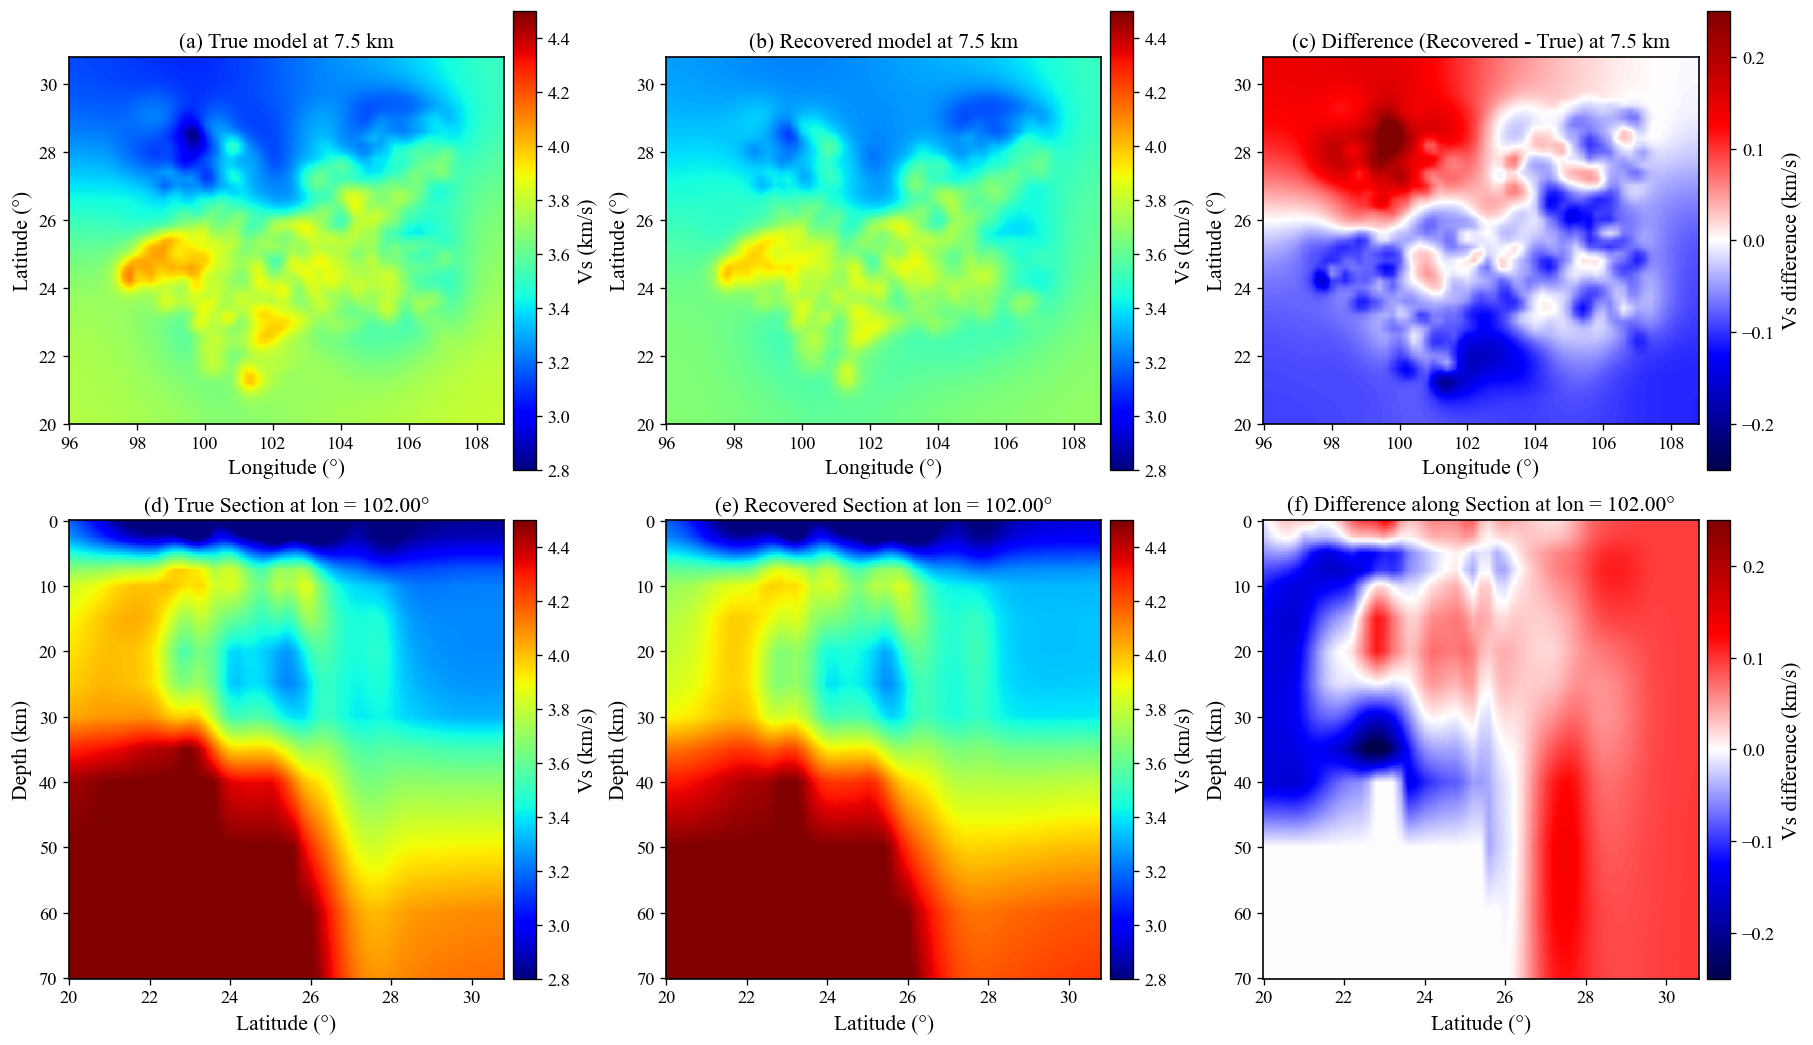

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.interpolate import RegularGridInterpolator


# =========================================================
# 1. 读取四列模型
# =========================================================
def read_vs_dat(dat_file):
    """
    读取四列格式:
    lon lat dep vs
    """
    data = np.loadtxt(dat_file)
    lon = data[:, 0]
    lat = data[:, 1]
    dep = data[:, 2]
    vs = data[:, 3]
    return lon, lat, dep, vs


def build_3d_model(lon, lat, dep, vs):
    """
    构造成规则网格:
    vs_3d[idep, ilon, ilat]

    约定:
      lon 升序
      lat 降序（北->南）
      dep 升序
    """
    lons = np.sort(np.unique(np.round(lon, 6)))
    lats = np.sort(np.unique(np.round(lat, 6)))[::-1]
    deps = np.sort(np.unique(np.round(dep, 6)))

    lon_to_i = {v: i for i, v in enumerate(lons)}
    lat_to_i = {v: i for i, v in enumerate(lats)}
    dep_to_i = {v: i for i, v in enumerate(deps)}

    vs_3d = np.full((len(deps), len(lons), len(lats)), np.nan)

    for lo, la, de, vv in zip(lon, lat, dep, vs):
        i_lon = lon_to_i[round(lo, 6)]
        i_lat = lat_to_i[round(la, 6)]
        i_dep = dep_to_i[round(de, 6)]
        vs_3d[i_dep, i_lon, i_lat] = vv

    return lons, lats, deps, vs_3d


# =========================================================
# 2. 二维规则网格插值
# =========================================================
def interpolate_2d(x, y, z, nx_new=400, ny_new=400):
    """
    输入:
      x: 1D
      y: 1D
      z: shape = (ny, nx)
    返回:
      Xnew, Ynew, Znew
    """
    x_in = np.array(x)
    y_in = np.array(y)
    z_in = np.array(z)

    if np.any(np.diff(x_in) < 0):
        ix = np.argsort(x_in)
        x_in = x_in[ix]
        z_in = z_in[:, ix]

    if np.any(np.diff(y_in) < 0):
        iy = np.argsort(y_in)
        y_in = y_in[iy]
        z_in = z_in[iy, :]

    interp = RegularGridInterpolator(
        (y_in, x_in),
        z_in,
        method="linear",
        bounds_error=False,
        fill_value=np.nan
    )

    x_new = np.linspace(x_in.min(), x_in.max(), nx_new)
    y_new = np.linspace(y_in.min(), y_in.max(), ny_new)
    Xnew, Ynew = np.meshgrid(x_new, y_new)

    pts = np.column_stack([Ynew.ravel(), Xnew.ravel()])
    Znew = interp(pts).reshape(Ynew.shape)

    return Xnew, Ynew, Znew


# =========================================================
# 3. 统一风格
# =========================================================
def set_plot_style():
    rcParams["font.family"] = "Times New Roman"
    rcParams["font.size"] = 12
    rcParams["axes.labelsize"] = 13
    rcParams["axes.titlesize"] = 13
    rcParams["xtick.labelsize"] = 11
    rcParams["ytick.labelsize"] = 11
    rcParams["figure.dpi"] = 120


# =========================================================
# 4. 主绘图函数
# =========================================================
def plot_true_vs_recovered(
    true_file,
    rec_file,
    target_depth,
    section_mode="lon",     # "lon" 或 "lat"
    section_value=102.0,    # 如果 mode="lon"，表示固定经度；如果 mode="lat"，表示固定纬度
    out_png=None,
    out_pdf=None,
    vmin=None,
    vmax=None,
    diff_clip=None,
    interp_slice_nx=450,
    interp_slice_ny=450,
    interp_sec_nx=450,
    interp_sec_ny=280
):
    """
    画 2x3 图:
      上排: depth slice (true / recovered / difference)
      下排: vertical section (true / recovered / difference)
    """
    set_plot_style()

    # ---------- 读两个模型 ----------
    lon_t, lat_t, dep_t, vs_t = read_vs_dat(true_file)
    lon_r, lat_r, dep_r, vs_r = read_vs_dat(rec_file)

    lons_t, lats_t, deps_t, true_3d = build_3d_model(lon_t, lat_t, dep_t, vs_t)
    lons_r, lats_r, deps_r, rec_3d = build_3d_model(lon_r, lat_r, dep_r, vs_r)

    # ---------- 检查网格一致性 ----------
    if not np.allclose(lons_t, lons_r):
        raise ValueError("真模型和恢复模型的 longitude 网格不一致")
    if not np.allclose(lats_t, lats_r):
        raise ValueError("真模型和恢复模型的 latitude 网格不一致")
    if not np.allclose(deps_t, deps_r):
        raise ValueError("真模型和恢复模型的 depth 网格不一致")

    lons = lons_t
    lats = lats_t
    deps = deps_t

    # ---------- 选深度层 ----------
    idep = np.argmin(np.abs(deps - target_depth))
    dep_sel = deps[idep]

    true_slice = true_3d[idep, :, :]   # [lon, lat]
    rec_slice = rec_3d[idep, :, :]
    diff_slice = rec_slice - true_slice

    # 转为 [lat, lon]
    TRUE_SLICE = true_slice.T
    REC_SLICE = rec_slice.T
    DIFF_SLICE = diff_slice.T

    Xs1, Ys1, TRUE_SLICE_I = interpolate_2d(
        lons, lats, TRUE_SLICE,
        nx_new=interp_slice_nx, ny_new=interp_slice_ny
    )
    Xs2, Ys2, REC_SLICE_I = interpolate_2d(
        lons, lats, REC_SLICE,
        nx_new=interp_slice_nx, ny_new=interp_slice_ny
    )
    Xs3, Ys3, DIFF_SLICE_I = interpolate_2d(
        lons, lats, DIFF_SLICE,
        nx_new=interp_slice_nx, ny_new=interp_slice_ny
    )

    # ---------- 纵剖面 ----------
    if section_mode.lower() == "lon":
        # 固定经度，画 lat-depth
        isec = np.argmin(np.abs(lons - section_value))
        sec_val = lons[isec]

        true_sec = true_3d[:, isec, :]     # [dep, lat]
        rec_sec = rec_3d[:, isec, :]
        diff_sec = rec_sec - true_sec

        # x=lat, y=dep
        Xt1, Yt1, TRUE_SEC_I = interpolate_2d(
            lats, deps, true_sec,
            nx_new=interp_sec_nx, ny_new=interp_sec_ny
        )
        Xt2, Yt2, REC_SEC_I = interpolate_2d(
            lats, deps, rec_sec,
            nx_new=interp_sec_nx, ny_new=interp_sec_ny
        )
        Xt3, Yt3, DIFF_SEC_I = interpolate_2d(
            lats, deps, diff_sec,
            nx_new=interp_sec_nx, ny_new=interp_sec_ny
        )

        xlab = "Latitude (°)"
        sec_title = f"Section at lon = {sec_val:.2f}°"

    elif section_mode.lower() == "lat":
        # 固定纬度，画 lon-depth
        isec = np.argmin(np.abs(lats - section_value))
        sec_val = lats[isec]

        true_sec = true_3d[:, :, isec]     # [dep, lon]
        rec_sec = rec_3d[:, :, isec]
        diff_sec = rec_sec - true_sec

        # x=lon, y=dep
        Xt1, Yt1, TRUE_SEC_I = interpolate_2d(
            lons, deps, true_sec,
            nx_new=interp_sec_nx, ny_new=interp_sec_ny
        )
        Xt2, Yt2, REC_SEC_I = interpolate_2d(
            lons, deps, rec_sec,
            nx_new=interp_sec_nx, ny_new=interp_sec_ny
        )
        Xt3, Yt3, DIFF_SEC_I = interpolate_2d(
            lons, deps, diff_sec,
            nx_new=interp_sec_nx, ny_new=interp_sec_ny
        )

        xlab = "Longitude (°)"
        sec_title = f"Section at lat = {sec_val:.2f}°"

    else:
        raise ValueError("section_mode 只能是 'lon' 或 'lat'")

    # ---------- 色标 ----------
    if vmin is None:
        vmin = np.nanmin([TRUE_SLICE_I, REC_SLICE_I, TRUE_SEC_I, REC_SEC_I])
    if vmax is None:
        vmax = np.nanmax([TRUE_SLICE_I, REC_SLICE_I, TRUE_SEC_I, REC_SEC_I])
    if diff_clip is None:
        diff_clip = np.nanmax(np.abs([DIFF_SLICE_I, DIFF_SEC_I]))

    # ---------- 画图 ----------
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.6), constrained_layout=True)

    # ===== 上排：横切面 =====
    im1 = axes[0, 0].pcolormesh(
        Xs1, Ys1, TRUE_SLICE_I, shading="auto",
        cmap="jet", vmin=vmin, vmax=vmax
    )
    axes[0, 0].set_title(f"(a) True model at {dep_sel:.1f} km")
    axes[0, 0].set_xlabel("Longitude (°)")
    axes[0, 0].set_ylabel("Latitude (°)")
    axes[0, 0].set_aspect("equal")
    cb1 = plt.colorbar(im1, ax=axes[0, 0], pad=0.02)
    cb1.set_label("Vs (km/s)")

    im2 = axes[0, 1].pcolormesh(
        Xs2, Ys2, REC_SLICE_I, shading="auto",
        cmap="jet", vmin=vmin, vmax=vmax
    )
    axes[0, 1].set_title(f"(b) Recovered model at {dep_sel:.1f} km")
    axes[0, 1].set_xlabel("Longitude (°)")
    axes[0, 1].set_ylabel("Latitude (°)")
    axes[0, 1].set_aspect("equal")
    cb2 = plt.colorbar(im2, ax=axes[0, 1], pad=0.02)
    cb2.set_label("Vs (km/s)")

    im3 = axes[0, 2].pcolormesh(
        Xs3, Ys3, DIFF_SLICE_I, shading="auto",
        cmap="seismic", vmin=-diff_clip, vmax=diff_clip
    )
    axes[0, 2].set_title(f"(c) Difference (Recovered - True) at {dep_sel:.1f} km")
    axes[0, 2].set_xlabel("Longitude (°)")
    axes[0, 2].set_ylabel("Latitude (°)")
    axes[0, 2].set_aspect("equal")
    cb3 = plt.colorbar(im3, ax=axes[0, 2], pad=0.02)
    cb3.set_label("Vs difference (km/s)")

    # ===== 下排：纵剖面 =====
    im4 = axes[1, 0].pcolormesh(
        Xt1, Yt1, TRUE_SEC_I, shading="auto",
        cmap="jet", vmin=vmin, vmax=vmax
    )
    axes[1, 0].set_title(f"(d) True {sec_title}")
    axes[1, 0].set_xlabel(xlab)
    axes[1, 0].set_ylabel("Depth (km)")
    axes[1, 0].invert_yaxis()
    cb4 = plt.colorbar(im4, ax=axes[1, 0], pad=0.02)
    cb4.set_label("Vs (km/s)")

    im5 = axes[1, 1].pcolormesh(
        Xt2, Yt2, REC_SEC_I, shading="auto",
        cmap="jet", vmin=vmin, vmax=vmax
    )
    axes[1, 1].set_title(f"(e) Recovered {sec_title}")
    axes[1, 1].set_xlabel(xlab)
    axes[1, 1].set_ylabel("Depth (km)")
    axes[1, 1].invert_yaxis()
    cb5 = plt.colorbar(im5, ax=axes[1, 1], pad=0.02)
    cb5.set_label("Vs (km/s)")

    im6 = axes[1, 2].pcolormesh(
        Xt3, Yt3, DIFF_SEC_I, shading="auto",
        cmap="seismic", vmin=-diff_clip, vmax=diff_clip
    )
    axes[1, 2].set_title(f"(f) Difference along {sec_title}")
    axes[1, 2].set_xlabel(xlab)
    axes[1, 2].set_ylabel("Depth (km)")
    axes[1, 2].invert_yaxis()
    cb6 = plt.colorbar(im6, ax=axes[1, 2], pad=0.02)
    cb6.set_label("Vs difference (km/s)")

    for ax in axes.ravel():
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"已保存: {out_png}")
    if out_pdf:
        plt.savefig(out_pdf, bbox_inches="tight")
        print(f"已保存: {out_pdf}")

    plt.show()


# =========================================================
# 5. 示例
# =========================================================
if __name__ == "__main__":
    true_file = "/public/home/xiangyy/Project_ZHv2.0/datasets_Yunnan/real_model_iter10.dat"
    rec_file = "/public/home/xiangyy/Project_ZHv2.0/datasets_Yunnan/syn_model_iter10.dat"

    plot_true_vs_recovered(
        true_file=true_file,
        rec_file=rec_file,
        target_depth=7.5,
        section_mode="lon",      # "lon" 或 "lat"
        section_value=102.0,     # 固定经度 102E；若 mode="lat"，这里就是固定纬度
        vmin=2.8,
        vmax=4.5,
        diff_clip=0.25,
        interp_slice_nx=500,
        interp_slice_ny=500,
        interp_sec_nx=500,
        interp_sec_ny=300
    )